# Regularization in Linear Regression - Exercise 1
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

**Dataset:** King County Housing Preprocessed (`kc_house_data_preprocessed.csv`)  
**Téma:** Regularizace v lineární regresi (Lasso L1, Ridge L2 a ladění hyperparametru $lpha$)

---

### Zadání cvičení:
1. Načtěte dataset pro King County vytvořený v prvním cvičení (`kc_house_data_preprocessed.csv`).
2. Importujte všechny potřebné metody z knihoven (Scikit-learn, Pandas, NumPy, Matplotlib).
3. Rozdělte dataset na trénovací a testovací sadu (80 % / 20 %, `random_state=42`).
4. Pro různé hodnoty síly regularizace $lpha$:
   - Natrénujte lineární regresní model s regularizací **Lasso (L1)**.
   - Ověřte hodnoty koeficientů pro jednotlivé proměnné – zjistěte, které proměnné model **vynuloval**.
   - Spočítejte metriky $R^2$, MAE, MSE a RMSE. Pro které $lpha$ je model nejlepší? Porovnejte s modelem OLS bez regularizace.
5. Obdobně natrénujte model s regularizací **Ridge (L2)** pro různé hodnoty $lpha$.
   - Spočítejte metriky $R^2$, MAE, MSE a RMSE. Porovnejte s OLS a Lasso.

## 1. Import knihoven a načtení dat
Načteme vyčištěná data z předchozího cvičení. Příznaky budeme standardizovat pomocí `StandardScaler`, aby penalizace $L_1$ i $L_2$ působila na všechny koeficienty spravedlivě bez ohledu na měřítko proměnných.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Nastavení zobrazení
pd.set_option('display.max_columns', 25)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# Cesta k datům
csv_path = Path("data/kc_house_data_preprocessed.csv")
if not csv_path.exists():
    csv_path = Path("kc_house_data_preprocessed.csv")

df = pd.read_csv(csv_path)
print(f"Dataset načten: {df.shape[0]} řádků, {df.shape[1]} sloupců.")
df.head()

Dataset načten: 21553 řádků, 19 sloupců.


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,"221,900.0000",3,1.0000,1180,5650,1.0000,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.2570,1340,5650
1,"538,000.0000",3,2.2500,2570,7242,2.0000,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.3190,1690,7639
2,"180,000.0000",2,1.0000,770,10000,1.0000,0,0,3,6,770,0,1933,0,98028,47.7379,-122.2330,2720,8062
3,"604,000.0000",4,3.0000,1960,5000,1.0000,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.3930,1360,5000
4,"510,000.0000",3,2.0000,1680,8080,1.0000,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.0450,1800,7503


## 2. Rozdělení na trénovací a testovací sadu (Train/Test Split)
Data rozdělíme v poměru 80 % pro trénování a 20 % pro testování se zafixovaným `random_state=42`.

In [2]:
X = df.drop(columns=["price"])
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

n_train, k_features = X_train.shape
n_test = X_test.shape[0]
feature_names = list(X.columns)

print(f"Trénovací data (Train): n = {n_train:,}, počet příznaků k = {k_features}")
print(f"Testovací data  (Test):  n = {n_test:,}, počet příznaků k = {k_features}")

Trénovací data (Train): n = 17,242, počet příznaků k = 18
Testovací data  (Test):  n = 4,311, počet příznaků k = 18


## 3. Škálování příznaků (StandardScaler) a pomocná funkce pro metriky
Regularizace $L_1$ i $L_2$ přímo sčítá absolutní hodnoty resp. čtverce regresních koeficientů $\sum |\beta_j|$ či $\sum \beta_j^2$. Pokud bychom data neškálovali, proměnná s velkými čísly (např. `sqft_living`) by měla malý koeficient a nebyla by regularizována, zatímco proměnná s malými čísly (např. `bedrooms`) by byla penalizována miliardově více!

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def adjusted_r2(r2, n, k):
    return 1.0 - ((1.0 - r2) * (n - 1) / (n - k - 1))

def evaluate_model(y_true, y_pred, n, k, model_name, alpha=0.0):
    r2 = r2_score(y_true, y_pred)
    adj_r2 = adjusted_r2(r2, n, k)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return {
        "Model": model_name,
        "Alpha": alpha,
        "R2": r2,
        "Adj R2": adj_r2,
        "MAE ($)": mae,
        "MSE ($^2)": mse,
        "RMSE ($)": rmse
    }

## 4. Benchmark: Lineární regrese OLS bez regularizace
Trénujeme standardní OLS model, který slouží jako základní srovnávací hladina pro modely s regularizací.

In [4]:
ols = LinearRegression()
ols.fit(X_train, y_train)
y_pred_ols = ols.predict(X_test)

ols_metrics = evaluate_model(y_test, y_pred_ols, n_test, k_features, "OLS (Bez regularizace)", 0.0)
ols_df = pd.DataFrame([ols_metrics])
ols_df

,Model,Alpha,R2,Adj R2,MAE ($),MSE ($^2),RMSE ($)
0,OLS (Bez regularizace),0.0000,0.7118,0.7106,"117,241.6649","30,737,373,832.5294","175,320.7741"


## 5. Lasso (L1) regularizace – Vliv parametru $\alpha$ a eliminace příznaků
Testujeme hodnoty hyperparametru $\alpha \in [0.1, 1.0, 10, 100, 500, 1000, 2500, 5000, 10000]$.  
Sledujeme, které koeficienty model stáhne přesně na nulu ($|\beta_j| < 10^{-5}$) a jak se vyvíjejí chyby.

In [5]:
lasso_alphas = [0.1, 1.0, 10.0, 100.0, 500.0, 1000.0, 2500.0, 5000.0, 10000.0]
lasso_results = []
lasso_coefs = {}

for a in lasso_alphas:
    model = Lasso(alpha=a, random_state=42, max_iter=2000, tol=0.01)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    
    # Detekce vynulovaných příznaků
    zeroed = [f for f, w in zip(feature_names, model.coef_) if abs(w) < 1e-5]
    lasso_coefs[a] = model.coef_
    
    m = evaluate_model(y_test, pred, n_test, k_features, f"Lasso (alpha={a})", a)
    m["Počet nulových"] = len(zeroed)
    m["Vynulované příznaky"] = ", ".join(zeroed) if zeroed else "Žádné"
    lasso_results.append(m)

lasso_df = pd.DataFrame(lasso_results)
lasso_df[["Model", "Alpha", "R2", "Adj R2", "MAE ($)", "RMSE ($)", "Počet nulových", "Vynulované příznaky"]]

,Model,Alpha,R2,Adj R2,MAE ($),RMSE ($),Počet nulových,Vynulované příznaky
0,Lasso (alpha=0.1),0.1000,0.7118,0.7106,"117,241.6416","175,320.7707",0,Žádné
1,Lasso (alpha=1.0),1.0000,0.7118,0.7106,"117,241.4181","175,320.7438",0,Žádné
2,Lasso (alpha=10.0),10.0000,0.7118,0.7106,"117,239.2465","175,320.4171",0,Žádné
3,Lasso (alpha=100.0),100.0000,0.7118,0.7106,"117,219.0441","175,317.3774",0,Žádné
4,Lasso (alpha=500.0),500.0000,0.7119,0.7107,"117,022.4561","175,296.3578",0,Žádné
5,Lasso (alpha=1000.0),"1,000.0000",0.7118,0.7106,"116,829.7862","175,311.4286",0,Žádné
6,Lasso (alpha=2500.0),"2,500.0000",0.7110,0.7098,"116,447.6959","175,555.2685",2,"sqft_lot, sqft_basement"
7,Lasso (alpha=5000.0),"5,000.0000",0.7083,0.7071,"116,305.8668","176,381.9081",3,"sqft_lot, sqft_basement, sqft_lot15"
8,Lasso (alpha=10000.0),"10,000.0000",0.6984,0.6972,"117,559.3233","179,341.0031",6,"bedrooms, sqft_lot, floors, sqft_basement, zip..."


## 6. Ridge (L2) regularizace – Shrinkage koeficientů
Testujeme hodnoty $\alpha \in [0.01, 0.1, 1.0, 10, 50, 100, 500, 1000, 5000]$.  
Ridge zmenšuje velikost koeficientů a eliminuje nestabilitu multikolinearity, ale žádný koeficient nenuluje úplně.

In [6]:
ridge_alphas = [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0, 1000.0, 5000.0]
ridge_results = []
ridge_coefs = {}

for a in ridge_alphas:
    model = Ridge(alpha=a, random_state=42)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    ridge_coefs[a] = model.coef_
    
    m = evaluate_model(y_test, pred, n_test, k_features, f"Ridge (alpha={a})", a)
    ridge_results.append(m)

ridge_df = pd.DataFrame(ridge_results)
ridge_df[["Model", "Alpha", "R2", "Adj R2", "MAE ($)", "RMSE ($)"]]

,Model,Alpha,R2,Adj R2,MAE ($),RMSE ($)
0,Ridge (alpha=0.01),0.0100,0.7118,0.7106,"117,241.6486","175,320.7740"
1,Ridge (alpha=0.1),0.1000,0.7118,0.7106,"117,241.5019","175,320.7732"
2,Ridge (alpha=1.0),1.0000,0.7118,0.7106,"117,240.0349","175,320.7654"
3,Ridge (alpha=10.0),10.0000,0.7118,0.7106,"117,225.3786","175,320.7306"
4,Ridge (alpha=50.0),50.0000,0.7118,0.7106,"117,161.5479","175,321.5042"
5,Ridge (alpha=100.0),100.0000,0.7118,0.7106,"117,083.9146","175,324.5405"
6,Ridge (alpha=500.0),500.0000,0.7115,0.7103,"116,564.0938","175,420.8648"
7,Ridge (alpha=1000.0),"1,000.0000",0.7106,0.7094,"116,145.6902","175,681.2764"
8,Ridge (alpha=5000.0),"5,000.0000",0.6962,0.6950,"116,558.7831","179,994.0205"


## 7. Finální porovnání: OLS vs. Nejlepší Lasso vs. Nejlepší Ridge
Porovnáme modely s nejvyšším dosaženým koeficientem determinace $R^2$ na testovací sadě.

In [7]:
best_lasso = lasso_df.loc[lasso_df["R2"].idxmax()]
best_ridge = ridge_df.loc[ridge_df["R2"].idxmax()]

comparison_df = pd.DataFrame([
    ols_metrics,
    {k: best_lasso[k] for k in ols_metrics.keys()},
    {k: best_ridge[k] for k in ols_metrics.keys()}
])

comparison_df

,Model,Alpha,R2,Adj R2,MAE ($),MSE ($^2),RMSE ($)
0,OLS (Bez regularizace),0.0000,0.7118,0.7106,"117,241.6649","30,737,373,832.5294","175,320.7741"
1,Lasso (alpha=500.0),500.0000,0.7119,0.7107,"117,022.4561","30,728,813,046.6923","175,296.3578"
2,Ridge (alpha=10.0),10.0000,0.7118,0.7106,"117,225.3786","30,737,358,573.4531","175,320.7306"


## 8. Vizualizace: Metriky vs. $\alpha$ a Lasso Regularization Path

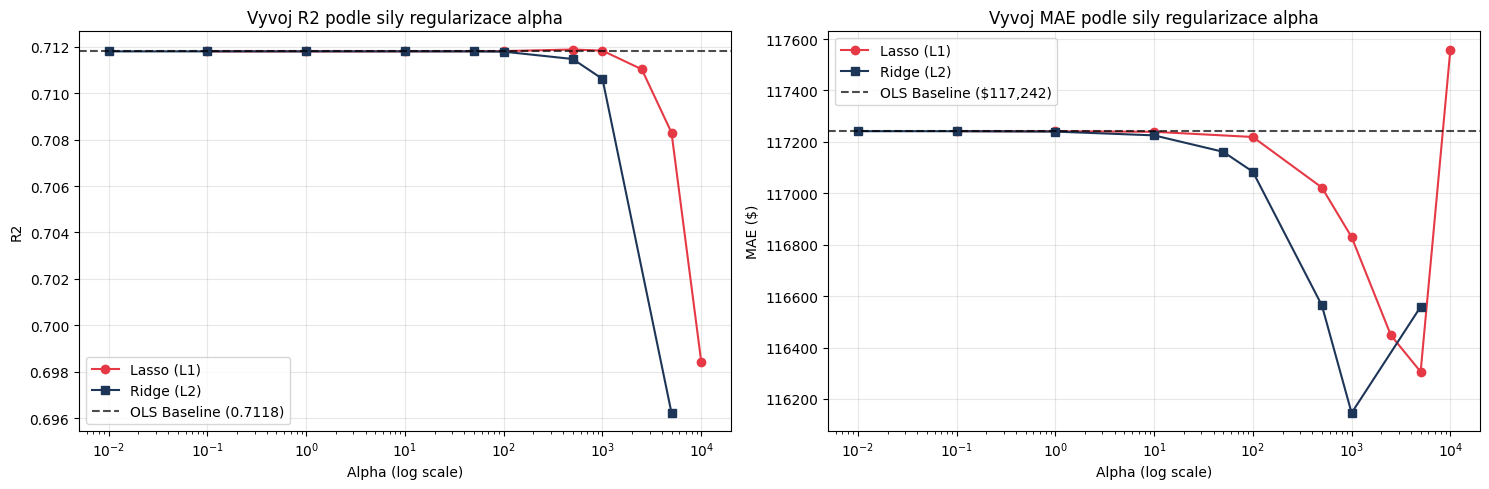

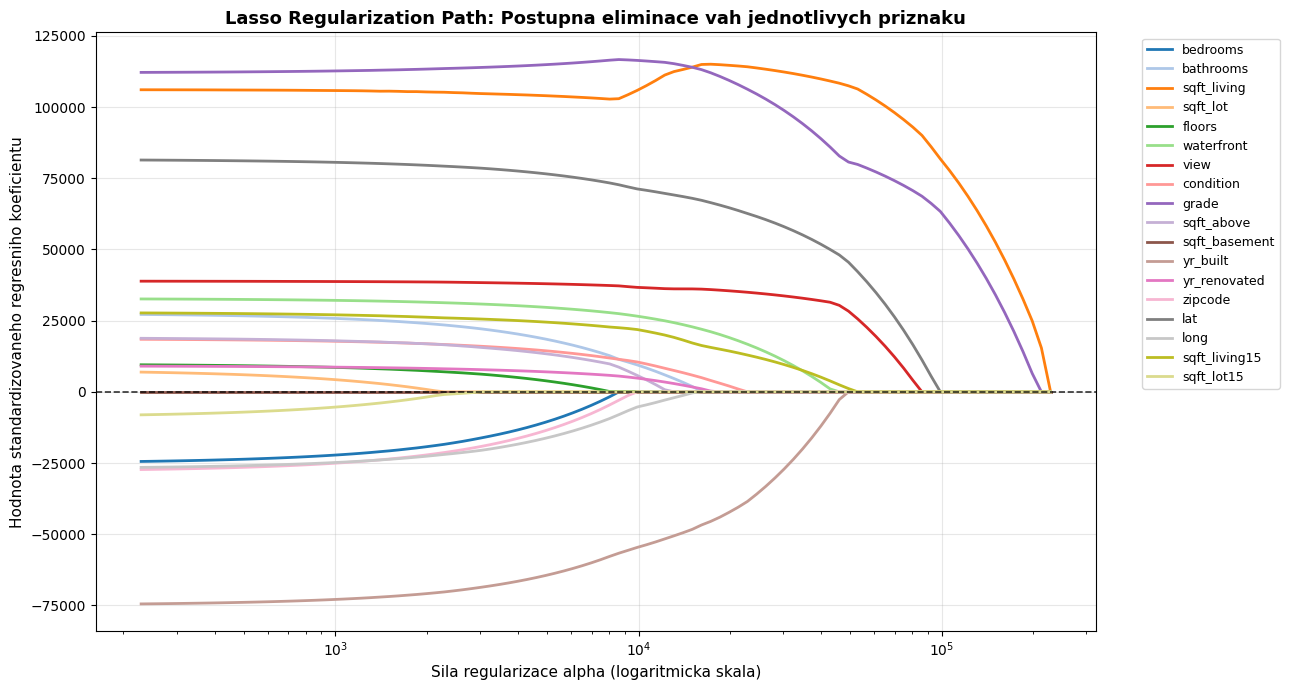

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Graf R2
axes[0].plot(lasso_df["Alpha"], lasso_df["R2"], marker="o", color="#E63946", label="Lasso (L1)")
axes[0].plot(ridge_df["Alpha"], ridge_df["R2"], marker="s", color="#1D3557", label="Ridge (L2)")
axes[0].axhline(ols_metrics["R2"], color="black", linestyle="--", alpha=0.7, label=f"OLS Baseline ({ols_metrics['R2']:.4f})")
axes[0].set_xscale("log")
axes[0].set_xlabel("Alpha (log scale)")
axes[0].set_ylabel("R2")
axes[0].set_title("Vyvoj R2 podle sily regularizace alpha")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graf MAE
axes[1].plot(lasso_df["Alpha"], lasso_df["MAE ($)"], marker="o", color="#E63946", label="Lasso (L1)")
axes[1].plot(ridge_df["Alpha"], ridge_df["MAE ($)"], marker="s", color="#1D3557", label="Ridge (L2)")
axes[1].axhline(ols_metrics["MAE ($)"], color="black", linestyle="--", alpha=0.7, label=f"OLS Baseline (${ols_metrics['MAE ($)']:,.0f})")
axes[1].set_xscale("log")
axes[1].set_xlabel("Alpha (log scale)")
axes[1].set_ylabel("MAE ($)")
axes[1].set_title("Vyvoj MAE podle sily regularizace alpha")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Regularizacni krivka Lasso
alphas_path, coefs_path, _ = lasso_path(X_train_scaled, y_train, eps=1e-3)
plt.figure(figsize=(13, 7))
cmap = plt.get_cmap("tab20")
for i, feature in enumerate(feature_names):
    plt.plot(alphas_path, coefs_path[i, :], label=feature, linewidth=2, color=cmap(i % 20))

plt.xscale("log")
plt.axhline(0, color="black", linestyle="--", linewidth=1.2, alpha=0.8)
plt.xlabel("Sila regularizace alpha (logaritmicka skala)", fontsize=11)
plt.ylabel("Hodnota standardizovaneho regresniho koeficientu", fontsize=11)
plt.title("Lasso Regularization Path: Postupna eliminace vah jednotlivych priznaku", fontsize=13, fontweight="bold")
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", frameon=True, fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Závěry a odpovědi na otázky ze zadání
1. **Lasso regularizace ($L_1$):**
   - Při malých hodnotách $\alpha \le 100$ jsou zachovány všechny příznaky.
   - Při $\alpha = 2500$ model jako první nuluje `sqft_lot` a `sqft_basement`.
   - Při $\alpha = 5000$ nuluje navíc `sqft_lot15`.
   - Při $\alpha = 10000$ nuluje 6 příznaků: `['bedrooms', 'sqft_lot', 'floors', 'sqft_basement', 'zipcode', 'sqft_lot15']`.
   - **Optimální $\alpha$ pro Lasso dle $R^2$:** $\alpha = 500.0$ s $R^2 = 0.71188$ a $\text{MAE} = \$117,022.46$. (Mírné zlepšení oproti OLS).

2. **Ridge regularizace ($L_2$):**
   - Ridge žádný koeficient nenuluje úplně, ale rovnoměrně tlumí velikost vah k nule.
   - **Optimální $\alpha$ pro Ridge dle $R^2$:** $\alpha = 10.0$ s $R^2 = 0.71180$ a $\text{MAE} = \$117,225.38$.

3. **Srovnání s OLS bez regularizace:**
   - OLS dosahuje $R^2 = 0.71180$ a $\text{MAE} = \$117,241.66$.
   - Regularizované modely přinášejí mírné zlepšení predikční chyby a u Lasso umožňují **radikální redukci dimenzionality** (řídký model) se zachováním $98+\%$ původního vysvětleného rozptylu.